In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv(r"C:\Users\sanay\Desktop\Mini Project\Batch B6 salaries.csv")

In [3]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [4]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [5]:
df.duplicated().sum()

42

In [6]:
df.dropna

<bound method DataFrame.dropna of      work_year experience_level employment_type                   job_title  \
0         2020               MI              FT              Data Scientist   
1         2020               SE              FT  Machine Learning Scientist   
2         2020               SE              FT           Big Data Engineer   
3         2020               MI              FT        Product Data Analyst   
4         2020               SE              FT   Machine Learning Engineer   
..         ...              ...             ...                         ...   
602       2022               SE              FT               Data Engineer   
603       2022               SE              FT               Data Engineer   
604       2022               SE              FT                Data Analyst   
605       2022               SE              FT                Data Analyst   
606       2022               MI              FT                AI Scientist   

     salary salar

In [7]:
df.duplicated().sum()

42

In [8]:
df.dropna().sum()

work_year                                                       1226993
experience_level      MISESEMISEENSEMIMISEENMIENMIMIMIENSEENMIMIMISE...
employment_type       FTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFT...
job_title             Data ScientistMachine Learning ScientistBig Da...
salary                                                        196668038
salary_currency       EURUSDGBPUSDUSDUSDUSDHUFUSDUSDEURINREURUSDUSDU...
salary_in_usd                                                  68164807
employee_residence    DEJPGBHNUSUSUSHUUSNZFRINFRUSUSPKJPPLINPTCNINGR...
remote_ratio                                                      43050
company_location      DEJPGBHNUSUSUSHUUSNZFRINFRUSUSPKJPGBINUSCNINGR...
company_size          LSMSLLSLLSSLMLLLSSMMMLLMLLLSLLSLLMLLLLSSSLMLLS...
dtype: object

In [9]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [10]:
df.duplicated().sum()


42

In [11]:
df = df.drop_duplicates()


In [12]:
df.duplicated().sum()

0

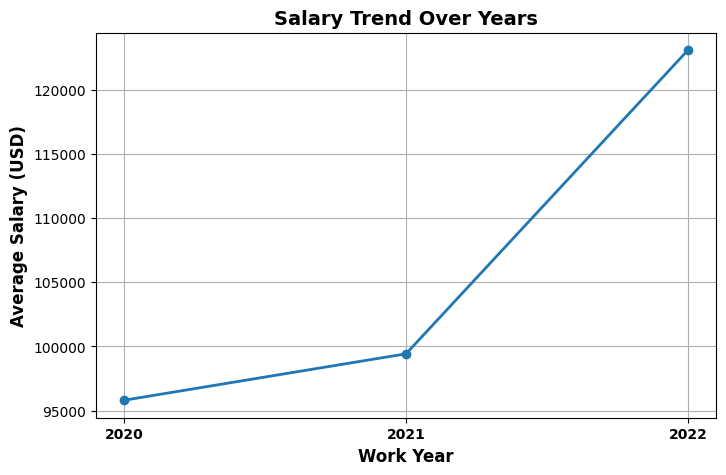

In [13]:
year_salary = df.groupby('work_year')['salary_in_usd'].mean().sort_index()

plt.figure(figsize=(8, 5))   # graph size increase
plt.plot(
    year_salary.index,
    year_salary.values,
    marker='o',
    linewidth=2
)

plt.xlabel("Work Year", fontsize=12, fontweight='bold')
plt.ylabel("Average Salary (USD)", fontsize=12, fontweight='bold')
plt.title("Salary Trend Over Years", fontsize=14, fontweight='bold')

plt.xticks(year_salary.index, fontsize=10, fontweight='bold')  # X-axis clear
plt.yticks(fontsize=10)

plt.grid(True)
plt.show()

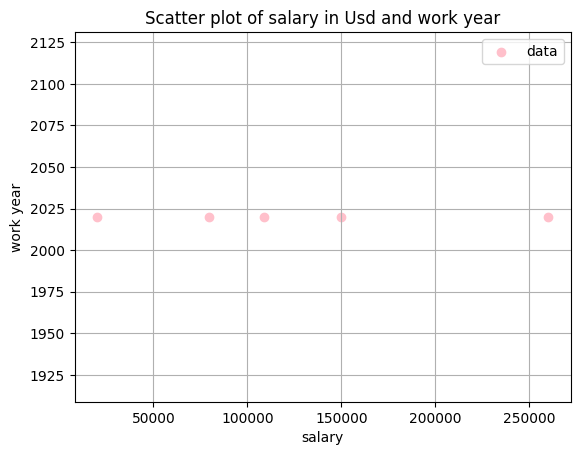

In [14]:
x = df['salary_in_usd'].head()
y = df['work_year'].head()
plt.scatter(x,y, marker = 'o', color = 'pink', label = 'data')
plt.xlabel('salary')
plt.ylabel('work year')
plt.title('Scatter plot of salary in Usd and work year')
plt.grid(True)
plt.legend()
plt.show()

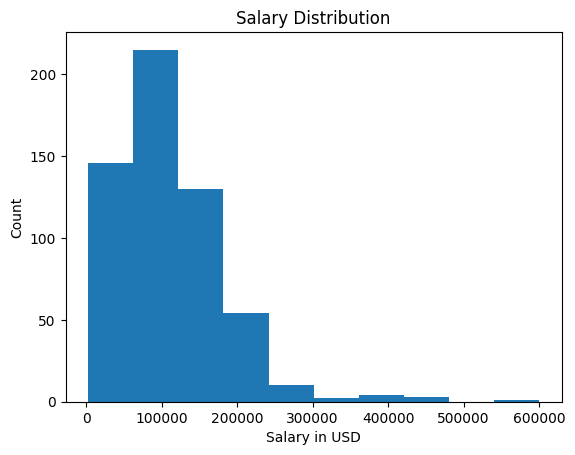

In [15]:
plt.hist(df['salary_in_usd'], bins=10)
plt.xlabel("Salary in USD")
plt.ylabel("Count")
plt.title("Salary Distribution")
plt.show()

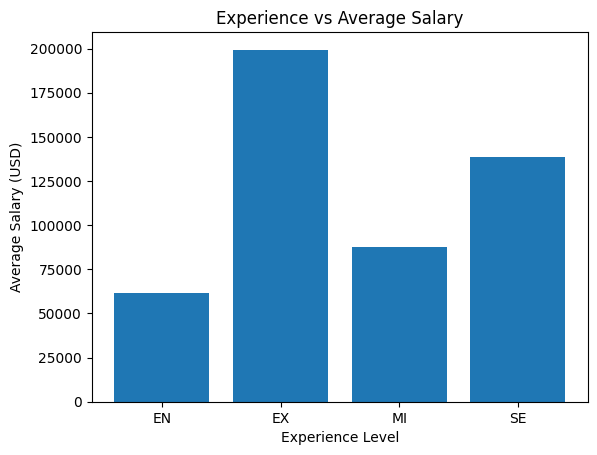

In [16]:
avg_salary = df.groupby('experience_level')['salary_in_usd'].mean()

plt.bar(avg_salary.index, avg_salary.values)
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.title("Experience vs Average Salary")
plt.show()

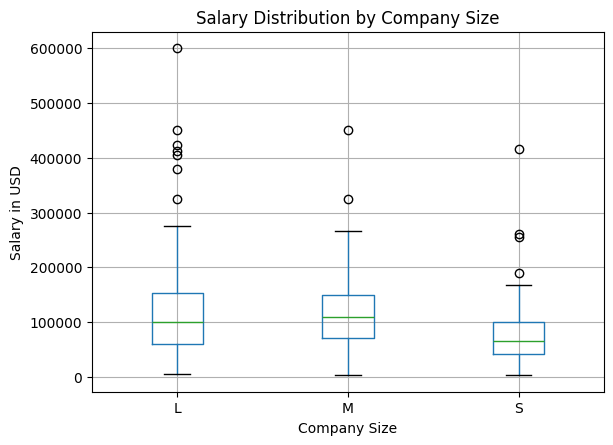

In [17]:
df.boxplot(column='salary_in_usd', by='company_size')

plt.xlabel("Company Size")
plt.ylabel("Salary in USD")
plt.title("Salary Distribution by Company Size")
plt.suptitle("")   # extra default title remove
plt.grid(True)

plt.show()

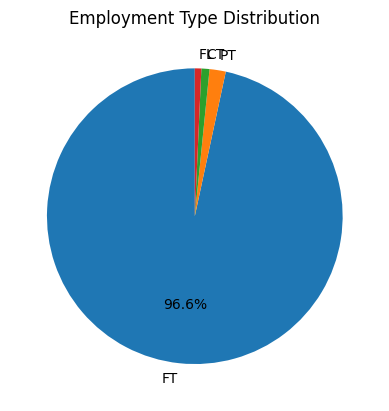

In [18]:
counts = df['employment_type'].value_counts()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90
)

plt.title("Employment Type Distribution")
plt.show()


In [19]:
encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df.loc[:, col] = le.fit_transform(df[col])  
    encoders[col] = le

joblib.dump(encoders, "model/label_encoders.pkl")

['model/label_encoders.pkl']

In [20]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,2,2,22,70000,7,79833,14,0,12,0
1,2020,3,2,41,260000,16,260000,32,0,29,2
2,2020,3,2,7,85000,8,109024,20,50,18,1
3,2020,2,2,47,20000,16,20000,23,0,20,2
4,2020,3,2,38,150000,16,150000,55,50,48,0
...,...,...,...,...,...,...,...,...,...,...,...
602,2022,3,2,17,154000,16,154000,55,100,48,1
603,2022,3,2,17,126000,16,126000,55,100,48,1
604,2022,3,2,12,129000,16,129000,55,0,48,1
605,2022,3,2,12,150000,16,150000,55,100,48,1


In [21]:
x=df.drop(['salary_in_usd'],axis=1)
y=df['salary_in_usd']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)
# Define empty lists to store metrics
mse_list = []
mae_list = []
r2_list = []
# Function to calculate various metrics such as mse. mae, r2 score etc
def calculatemetrics(algorithm, predict, testY):
    #testY = testY.astype('int')
    #predict = predict.astype('int')
    
    mse = mean_squared_error(testY, predict)
    mae = mean_absolute_error(testY, predict)
    r2 = r2_score(testY, predict) * 100
    
    # Append calculated metrics to lists
    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)
    
    print(algorithm + ' Mean Squared Error: ' + str(mse))
    print(algorithm + ' Mean Absolute Error: ' + str(mae))
    print(algorithm + ' R^2 Score: ' + str(r2))
    
    # Ensure that you are working with numpy arrays
    testY = np.array(testY)
    predict = np.array(predict)
    # Create a scatter plot
    plt.figure(figsize=(8, 8))
    plt.scatter(predict, testY,color='blue')
    plt.plot([np.min(testY), np.max(testY)], [np.min(testY), np.max(testY)], linestyle='--', color='red', lw=2)
    # Set labels and title
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Regression Performance')
    plt.show()

Pretrained model is loaded
K-Nearest Neighbors Classifier model Mean Squared Error: 1529613798.3479648
K-Nearest Neighbors Classifier model Mean Absolute Error: 12555.053097345135
K-Nearest Neighbors Classifier model R^2 Score: 68.158677792095


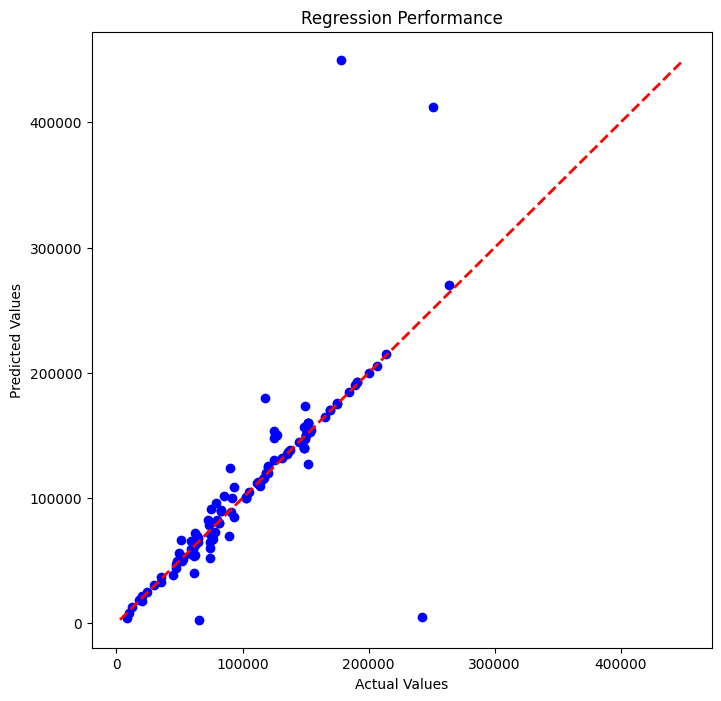

In [23]:
from sklearn.neighbors import KNeighborsRegressor
import joblib
import os

knn_model_path = 'model/KNN.joblib'

if os.path.exists(knn_model_path):
    KNN = joblib.load(knn_model_path)
    print('Pretrained model is loaded')
else:
    KNN = KNeighborsRegressor(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
    KNN.fit(x_train, y_train)
    joblib.dump(KNN, knn_model_path)

y_pred = KNN.predict(x_test)

# Evaluate the model
calculatemetrics('K-Nearest Neighbors Classifier model', y_pred, y_test)

Pretrained Linear Regression model is loaded
Linear Regression Mean Squared Error: 3224706302.8156333
Linear Regression Mean Absolute Error: 36943.905170374775
Linear Regression R^2 Score: 32.87265548682198


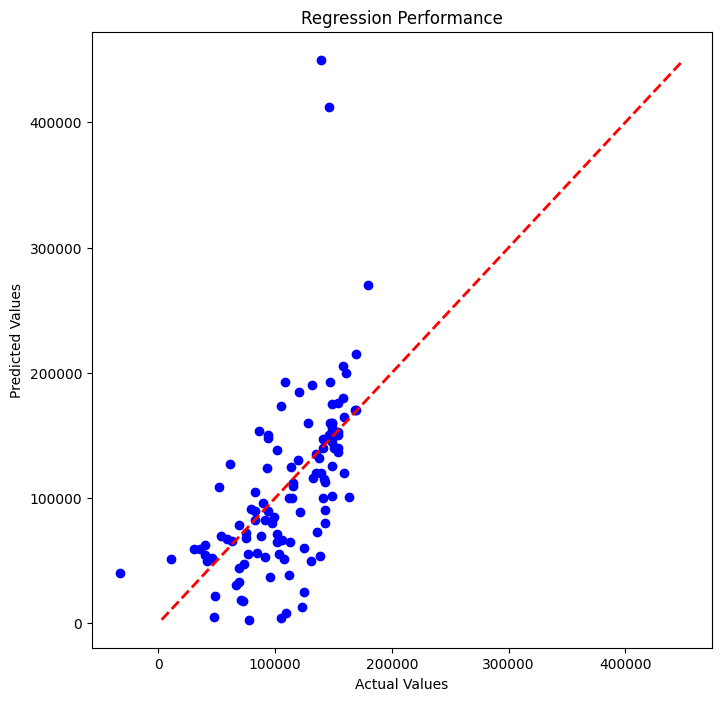

In [24]:
linear_model_path = "model/LinearRegression.joblib"
if os.path.exists(linear_model_path):
    linear = joblib.load(linear_model_path)
    print("Pretrained Linear Regression model is loaded")
else:
    linear = LinearRegression()
    linear.fit(X_train, y_train)
    joblib.dump(linear, linear_model_path)
    print("Linear Regression model trained and saved")
y_pred_lr = linear.predict(x_test)
calculatemetrics("Linear Regression", y_pred_lr, y_test)

Pretrained Huber Regression model is loaded
Huber Regression Mean Squared Error: 17278034571.24735
Huber Regression Mean Absolute Error: 108708.27204961503
Huber Regression R^2 Score: -259.6695234421887


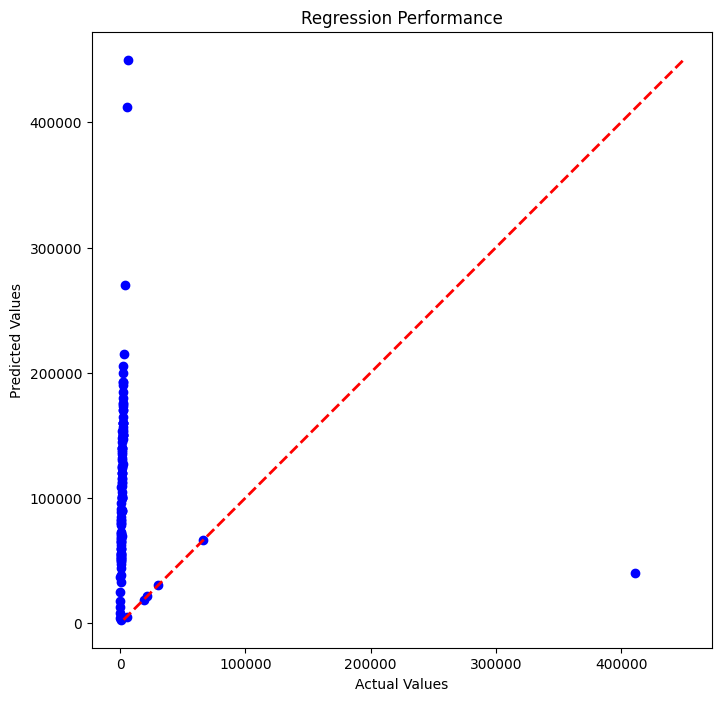

In [25]:
from sklearn.linear_model import HuberRegressor
huber_model_path = "model/HuberRegression.joblib"

if os.path.exists(huber_model_path):
    huber = joblib.load(huber_model_path)
    print("Pretrained Huber Regression model is loaded")
else:
    huber = HuberRegressor()
    huber.fit(x_train, y_train)
    joblib.dump(huber, huber_model_path)
    print("Huber Regression model trained and saved")
y_pred_hr = huber.predict(x_test)
calculatemetrics("Huber Regression", y_pred_hr, y_test)

Pretrained Hist Gradient Boosting Regressor model is loaded
Hist Gradient Boosting Regressor Mean Squared Error: 209979897.6585139
Hist Gradient Boosting Regressor Mean Absolute Error: 6513.639833609666
Hist Gradient Boosting Regressor R^2 Score: 95.6289374574492


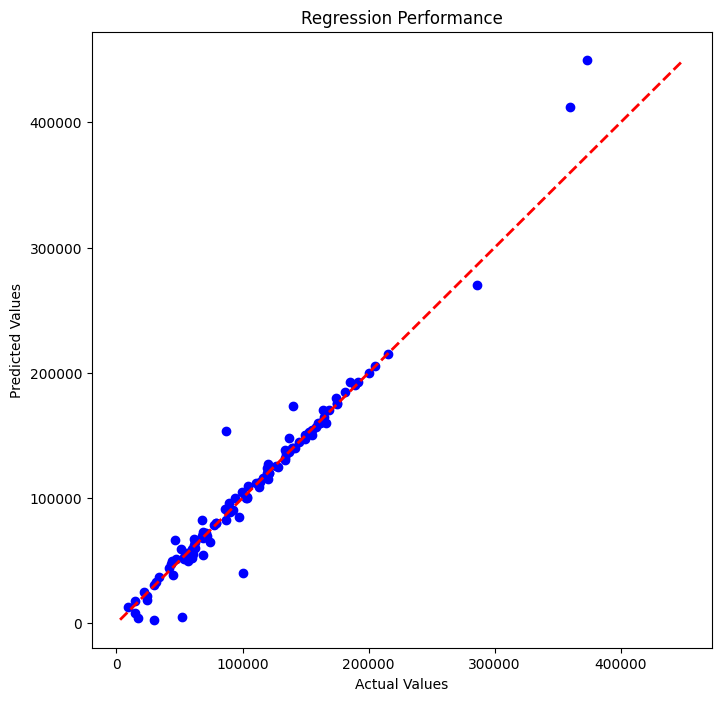

In [26]:
hgb_model_path = "model/HistGradientBoosting.joblib"
if os.path.exists(hgb_model_path):
    hgb = joblib.load(hgb_model_path)
    print("Pretrained Hist Gradient Boosting Regressor model is loaded")
else:
    hgb = HistGradientBoostingRegressor(random_state=42)
    hgb.fit(x_train, y_train)
    joblib.dump(hgb, hgb_model_path)
    print("Hist Gradient Boosting Regressor model trained and saved")

y_pred_hgb = hgb.predict(x_test)
calculatemetrics("Hist Gradient Boosting Regressor", y_pred_hgb, y_test)


In [27]:
testdata = pd.read_csv('test1.csv')
testdata

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
0,2022,0,2,17,52800,7,43,100,12,1
1,2021,1,0,46,416000,16,55,100,48,2
2,2021,0,2,17,2250000,10,27,100,25,0
3,2021,3,2,32,170000,16,55,100,48,0
4,2021,2,2,22,130000,16,55,50,48,0
5,2021,3,2,48,50000,16,19,100,48,2
6,2020,3,2,17,188000,16,55,100,48,0
7,2022,2,2,12,30000,8,20,100,18,1
8,2020,3,2,38,40000,7,24,100,21,2
9,2022,0,2,22,120000,0,3,50,3,1


In [28]:
pred = hgb.predict(testdata)
pred

array([ 59621.12305836, 378118.84470461,  29924.59430699, 168474.29804659,
       132541.52715278,  57092.03383741, 186769.87052198,  38602.21332122,
        46778.55316937,  96758.53756287, 146220.0096497 , 150432.12019207,
        59655.56071178, 136751.90534978,  73219.71847727,  31586.09649251,
       149476.85388324, 213704.32709122, 157430.2395945 , 107818.9864626 ])

In [29]:
testdata['Predicted salary in usd'] = pred.round().astype(int)
testdata

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,Predicted salary in usd
0,2022,0,2,17,52800,7,43,100,12,1,59621
1,2021,1,0,46,416000,16,55,100,48,2,378119
2,2021,0,2,17,2250000,10,27,100,25,0,29925
3,2021,3,2,32,170000,16,55,100,48,0,168474
4,2021,2,2,22,130000,16,55,50,48,0,132542
5,2021,3,2,48,50000,16,19,100,48,2,57092
6,2020,3,2,17,188000,16,55,100,48,0,186770
7,2022,2,2,12,30000,8,20,100,18,1,38602
8,2020,3,2,38,40000,7,24,100,21,2,46779
9,2022,0,2,22,120000,0,3,50,3,1,96759
